## **IMPORTS :**

In [21]:
# ===============================
# 1. Import Libraries
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)

## **DATA LOADING:**

In [23]:
import pandas as pd

path = "/content/Public_Safety_-_Police_Incidents_20251104.csv"

def safe_read_csv_fixed(path):
    encodings = ["utf-8", "utf-8-sig", "latin-1"]
    delims = [",", "\t", ";", "|"]
    last_err = None

    # Trying multiple combinations
    for enc in encodings:
        for d in delims:
            try:
                df = pd.read_csv(
                    path,
                    sep=d,
                    encoding=enc,
                    engine="python",
                    on_bad_lines="skip",  # skip malformed lines
                    quotechar='"',
                    escapechar="\\"
                )
                print(f"Loaded with sep='{d}', encoding='{enc}'")
                return df
            except Exception as e:
                last_err = e

    raise RuntimeError(f"Could not read CSV. Last error: {last_err}")

# Use it
df = safe_read_csv_fixed(path)
print("\n Dataset Loaded Successfully!")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

df = df[df['City'].str.contains("dallas", case=False, na=False)]
print("\nFiltered rows shape:", df.shape)
df.head()


Loaded with sep=',', encoding='utf-8'

 Dataset Loaded Successfully!
Shape: (1412638, 78)

Columns: ['Incident Number w/year', 'Year of Incident', 'Service Number ID', 'Watch', 'Call (911) Problem', 'Type of Incident', 'Type  Location', 'Type of Property', 'Incident Address', 'Apartment Number', 'Reporting Area', 'Beat', 'Division', 'Sector', 'Council District', 'Target Area Action Grids', 'Community', 'Year1 of Occurrence', 'Month1 of Occurence', 'Day1 of the Week', 'Time1 of Occurrence', 'Day1 of the Year', 'Year2 of Occurrence', 'Month2 of Occurence', 'Day2 of the Week', 'Time2 of Occurrence', 'Day2 of the Year', 'Offense Entered Year', 'Offense Entered Month', 'Offense Entered Day of the Week', 'Offense Entered Time', 'Offense Entered  Date/Time', 'CFS Number', 'Special Report (Pre-RMS)', 'Person Involvement Type', 'Victim Type', 'Victim Race', 'Victim Ethnicity', 'Victim Gender', 'Responding Officer #1  Badge No', 'Responding Officer #1  Name', 'Responding Officer #2 Badge No', 'R

,Incident Number w/year,Year of Incident,Service Number ID,Watch,Call (911) Problem,Type of Incident,Type Location,Type of Property,Incident Address,Apartment Number,Reporting Area,Beat,Division,Sector,Council District,Target Area Action Grids,Community,Year1 of Occurrence,Month1 of Occurence,Day1 of the Week,Time1 of Occurrence,Day1 of the Year,Year2 of Occurrence,Month2 of Occurence,Day2 of the Week,Time2 of Occurrence,Day2 of the Year,Offense Entered Year,Offense Entered Month,Offense Entered Day of the Week,Offense Entered Time,Offense Entered Date/Time,CFS Number,Special Report (Pre-RMS),Person Involvement Type,Victim Type,Victim Race,Victim Ethnicity,Victim Gender,Responding Officer #1 Badge No,Responding Officer #1 Name,Responding Officer #2 Badge No,Responding Officer #2 Name,Reporting Officer Badge No,Assisting Officer Badge No,Reviewing Officer Badge No,Element Number Assigned,Investigating Unit 1,Investigating Unit 2,Offense Status,UCR Disposition,Modus Operandi (MO),Family Offense,Hate Crime,Hate Crime Description,Weapon Used,Gang Related Offense,Drug Related Istevencident,RMS Code,Criminal Justice Information Service Code,Penal Code,UCR Offense Name,UCR Offense Description,UCR Code,Offense Type,NIBRS Crime,NIBRS Crime Category,NIBRS Crime Against,NIBRS Code,NIBRS Group,NIBRS Type,Update Date,X Coordinate,Y Cordinate,Zip Code,City,State,Location1
0,184761-2019,2019,184761-2019-01,1,11R/01 - BURG OF RES,BURGLARY OF HABITATION -NO FORCED ENTRY,Single Family Residence - Vacant,Other,5615 PLEASANT RIDGE DR,NaN,4311.0,433.0,SOUTHWEST,430.0,D3,NaN,NaN,2019,September,Wed,00:00,254,2019.0,September,Wed,00:05,254.0,2019,September,Wed,01:04,254,19-1710598,NaN,Victim,Individual,Hispanic or Latino,Hispanic or Latino,Male,9489,"MIXON,JAMIE,LAVOR",9375,"HILBURN,ARCHIE,LESTER",9489,10295,15356,A454,Investigations,Property Crime Division / SW Property Crimes,Suspended,Suspended,UNK SUSP ENTERED THE COMP'S RESIDENCE AND TOOK...,False,NaN,NaN,NaN,NaN,No,F2-22990002-E6,22990002.0,PC 30.02(c)(2),NaN,NaN,NaN,NaN,BURGLARY-RESIDENCE,BURGLARY/ BREAKING & ENTERING,PROPERTY,220,A,Coded,2019-10-30 18:21:11.0000000,2.450580e+06,6.933317e+06,75236.0,DALLAS,TX,POINT (-96.933063006 32.678317997)
1,152050-2017,2017,152050-2017-01,1,6XA - MAJOR DIST AMBULANCE,ASSAULT (AGG) -SERIOUS BODILY INJURY,Parking Lot (All Others),NaN,2650 CEDAR SPRINGS RD,7727,2038.0,122.0,CENTRAL,120.0,D14,McKinney Allen,NaN,2017,July,Wed,00:35,186,2017.0,July,Wed,01:03,186.0,2017,July,Wed,01:17,186,17-1275816,NaN,Victim,Individual,Black,Non-Hispanic or Latino,Male,7614,"FORGE,ELLIOTT,WAYANE",NaN,NaN,7614,7129,77397,A102,Investigations,Capers / Assaults,Suspended,Suspended,UNKNOWN BLACK SUSPECT ASSAULTED VICTIM.,False,NaN,NaN,Personal Weapons (Hands-Feet ETC),No,No,F2-13150004-D3,13150004.0,PC 22.02(a)(1),AGG ASSAULT - NFV,AGGRAVATED ASSAULT,400.0,PART1,AGG ASSAULT - NFV,ASSAULT OFFENSES,PERSON,13A,A,Coded,2018-08-30 17:40:57.0000000,2.489363e+06,6.978343e+06,75204.0,DALLAS,TX,POINT (-96.804703966 32.800491989)
2,067980-2020,2020,067980-2020-01,3,PSE/40 - OTHER,THEFT - PRELIMINARY INVESTIGATION,Other,NaN,19019 PRESTON RD,516,6008.0,621.0,NORTH CENTRAL,620.0,D12,NaN,NaN,2020,April,Tue,18:00,105,2020.0,April,Tue,18:26,105.0,2020,April,Tue,20:25,105,20-0676618,NaN,Victim,Individual,Black,Non-Hispanic or Latino,Female,11137,"PRENSA,MANUEL",NaN,NaN,11137,9857,121912,EX04,Investigations,Special Investigations / Financial Crimes,Suspended,Suspended,UNK SUSP USED COMPS BANK LOGIN INFORMATION TO ...,False,NaN,NaN,NaN,NaN,No,NA-99999999-Z25,99999999.0,Theft Investigation,NaN,NaN,NaN,NaN,MISCELLANEOUS,MISCELLANEOUS,MISCELLANEOUS,999,C,999 - No Coded,2020-11-11 20:46:04.0000000,2.490479e+06,7.053406e+06,75252.0,DALLAS,TX,POINT (-96.797128989 33.006674989)
3,149459-2023,2023,149459-2023-01,1,41/11R - BURG RES IN PROGRESS,CRIM MISCHIEF > OR EQUAL $100 < $750,Apartment Complex/Building,NaN,839 S GOOD LATIMER EXPY,2324,2089.0,135.0,CENTRAL,130.0,D2,NaN,NaN,2023,August,Sat,03:45,231,2023.0

# **DATA PREPROCESSING:**

In [24]:
# ===============================
#  3. Basic Data Understanding
# ===============================
print("\n Dataset Info:")
print(df.info())

print("\n Missing Values:")
print(df.isnull().sum())


 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 1404184 entries, 0 to 1412637
Data columns (total 78 columns):
 #   Column                                     Non-Null Count    Dtype  
---  ------                                     --------------    -----  
 0   Incident Number w/year                     1404184 non-null  object 
 1   Year of Incident                           1404184 non-null  int64  
 2   Service Number ID                          1404184 non-null  object 
 3   Watch                                      1404184 non-null  object 
 4   Call (911) Problem                         1287413 non-null  object 
 5   Type of Incident                           1404144 non-null  object 
 6   Type  Location                             1402751 non-null  object 
 7   Type of Property                           275481 non-null   object 
 8   Incident Address                           1404176 non-null  object 
 9   Apartment Number                           316215 non-nul

In [25]:
# ===============================
# 4. Data Cleaning
# ===============================
# Remove duplicates
df.drop_duplicates(inplace=True)
print("Shape after removing duplicates :",df.shape)

# Drop rows with all null values
df.dropna(how='all', inplace=True)
print("Shape after removing NULL values :",df.shape)
# Fill nulls only for specific columns that normally contain text
fill_cols = [col for col in df.columns if df[col].dtype == 'object']
df[fill_cols] = df[fill_cols].fillna('Unknown')

# Drop invalid / future years
invalid_years = [1014, 1011, 2026]
df = df[~df['Year of Incident'].isin(invalid_years)]
print("Removed invalid years. Shape:", df.shape)

# Drop hate crime columns (if present)
cols_to_drop = ['Hate Crime', 'Hate Crime Description']
df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True, errors='ignore')
print("Dropped hate crime columns (if existed). Shape:", df.shape)

# Remove duplicate rows
df.drop_duplicates(inplace=True)
print("Removed duplicates. Final Shape:", df.shape)

#  Display few rows to confirm
print("\n Data Cleaning Completed!")
display(df.head())

Shape after removing duplicates : (1404184, 78)
Shape after removing NULL values : (1404184, 78)
Removed invalid years. Shape: (1404180, 78)
Dropped hate crime columns (if existed). Shape: (1404180, 76)
Removed duplicates. Final Shape: (1404180, 76)

 Data Cleaning Completed!


,Incident Number w/year,Year of Incident,Service Number ID,Watch,Call (911) Problem,Type of Incident,Type Location,Type of Property,Incident Address,Apartment Number,Reporting Area,Beat,Division,Sector,Council District,Target Area Action Grids,Community,Year1 of Occurrence,Month1 of Occurence,Day1 of the Week,Time1 of Occurrence,Day1 of the Year,Year2 of Occurrence,Month2 of Occurence,Day2 of the Week,Time2 of Occurrence,Day2 of the Year,Offense Entered Year,Offense Entered Month,Offense Entered Day of the Week,Offense Entered Time,Offense Entered Date/Time,CFS Number,Special Report (Pre-RMS),Person Involvement Type,Victim Type,Victim Race,Victim Ethnicity,Victim Gender,Responding Officer #1 Badge No,Responding Officer #1 Name,Responding Officer #2 Badge No,Responding Officer #2 Name,Reporting Officer Badge No,Assisting Officer Badge No,Reviewing Officer Badge No,Element Number Assigned,Investigating Unit 1,Investigating Unit 2,Offense Status,UCR Disposition,Modus Operandi (MO),Family Offense,Weapon Used,Gang Related Offense,Drug Related Istevencident,RMS Code,Criminal Justice Information Service Code,Penal Code,UCR Offense Name,UCR Offense Description,UCR Code,Offense Type,NIBRS Crime,NIBRS Crime Category,NIBRS Crime Against,NIBRS Code,NIBRS Group,NIBRS Type,Update Date,X Coordinate,Y Cordinate,Zip Code,City,State,Location1
0,184761-2019,2019,184761-2019-01,1,11R/01 - BURG OF RES,BURGLARY OF HABITATION -NO FORCED ENTRY,Single Family Residence - Vacant,Other,5615 PLEASANT RIDGE DR,Unknown,4311.0,433.0,SOUTHWEST,430.0,D3,Unknown,Unknown,2019,September,Wed,00:00,254,2019.0,September,Wed,00:05,254.0,2019,September,Wed,01:04,254,19-1710598,Unknown,Victim,Individual,Hispanic or Latino,Hispanic or Latino,Male,9489,"MIXON,JAMIE,LAVOR",9375,"HILBURN,ARCHIE,LESTER",9489,10295,15356,A454,Investigations,Property Crime Division / SW Property Crimes,Suspended,Suspended,UNK SUSP ENTERED THE COMP'S RESIDENCE AND TOOK...,False,Unknown,Unknown,No,F2-22990002-E6,22990002.0,PC 30.02(c)(2),Unknown,Unknown,NaN,Unknown,BURGLARY-RESIDENCE,BURGLARY/ BREAKING & ENTERING,PROPERTY,220,A,Coded,2019-10-30 18:21:11.0000000,2.450580e+06,6.933317e+06,75236.0,DALLAS,TX,POINT (-96.933063006 32.678317997)
1,152050-2017,2017,152050-2017-01,1,6XA - MAJOR DIST AMBULANCE,ASSAULT (AGG) -SERIOUS BODILY INJURY,Parking Lot (All Others),Unknown,2650 CEDAR SPRINGS RD,7727,2038.0,122.0,CENTRAL,120.0,D14,McKinney Allen,Unknown,2017,July,Wed,00:35,186,2017.0,July,Wed,01:03,186.0,2017,July,Wed,01:17,186,17-1275816,Unknown,Victim,Individual,Black,Non-Hispanic or Latino,Male,7614,"FORGE,ELLIOTT,WAYANE",Unknown,Unknown,7614,7129,77397,A102,Investigations,Capers / Assaults,Suspended,Suspended,UNKNOWN BLACK SUSPECT ASSAULTED VICTIM.,False,Personal Weapons (Hands-Feet ETC),No,No,F2-13150004-D3,13150004.0,PC 22.02(a)(1),AGG ASSAULT - NFV,AGGRAVATED ASSAULT,400.0,PART1,AGG ASSAULT - NFV,ASSAULT OFFENSES,PERSON,13A,A,Coded,2018-08-30 17:40:57.0000000,2.489363e+06,6.978343e+06,75204.0,DALLAS,TX,POINT (-96.804703966 32.800491989)
2,067980-2020,2020,067980-2020-01,3,PSE/40 - OTHER,THEFT - PRELIMINARY INVESTIGATION,Other,Unknown,19019 PRESTON RD,516,6008.0,621.0,NORTH CENTRAL,620.0,D12,Unknown,Unknown,2020,April,Tue,18:00,105,2020.0,April,Tue,18:26,105.0,2020,April,Tue,20:25,105,20-0676618,Unknown,Victim,Individual,Black,Non-Hispanic or Latino,Female,11137,"PRENSA,MANUEL",Unknown,Unknown,11137,9857,121912,EX04,Investigations,Special Investigations / Financial Crimes,Suspended,Suspended,UNK SUSP USED COMPS BANK LOGIN INFORMATION TO ...,False,Unknown,Unknown,No,NA-99999999-Z25,99999999.0,Theft Investigation,Unknown,Unknown,NaN,Unknown,MISCELLANEOUS,MISCELLANEOUS,MISCELLANEOUS,999,C,999 - No Coded,2020-11-11 20:46:04.0000000,2.490479e+06,7.053406e+06,75252.0,DALLAS,TX,POINT (-96.797128989 33.006674989)
3,149459-2023,2023,149459-2023-01,1,41/11R - BURG RES IN PROGRESS,CRIM MISCHIEF > OR EQUAL $100 < $750,Apartment Complex/Building,Unknown,839 S GOOD LATIMER EXPY,2324,2089.0,135.0,CENTRAL,130

# **EXPLORATORY DATA ANALYSIS:**

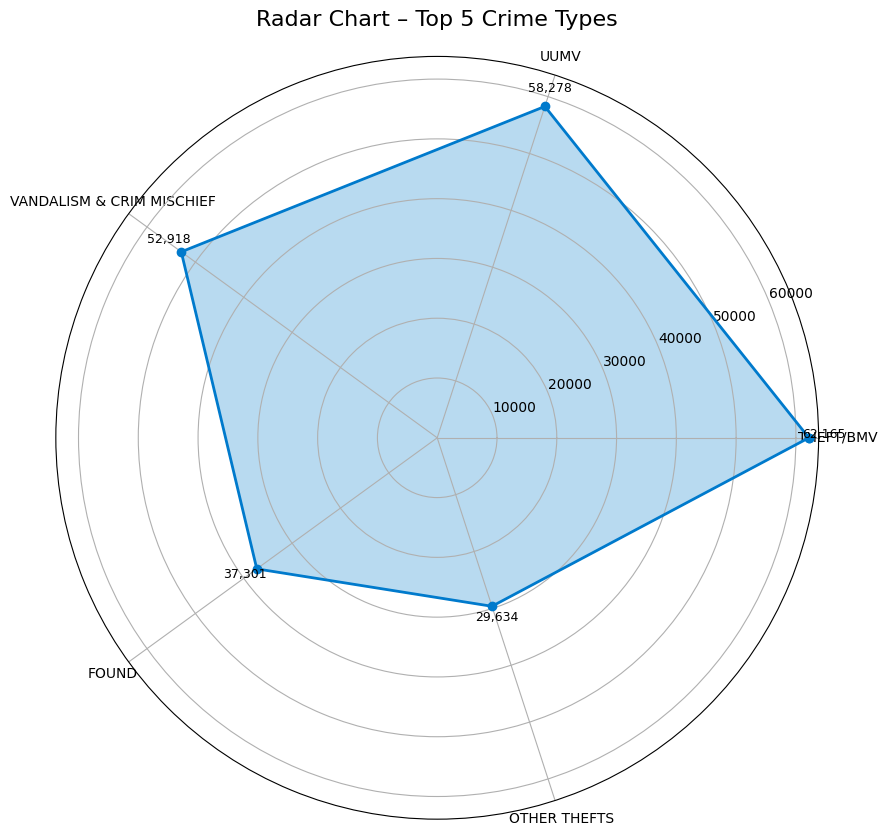

In [26]:
# ============================================================
# TOP CRIME TYPES
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Filter & get Top 5 crime types (excluding Unknown)
crime_counts = df[df['UCR Offense Name'].str.lower() != "unknown"]['UCR Offense Name'].value_counts().head(5)

labels = crime_counts.index.tolist()
values = crime_counts.values.tolist()

# Close the polygon by repeating first value
values += values[:1]

# Angle for each category axis
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(9, 9))

# Draw radar shape
plt.polar(angles, values, marker='o', linewidth=2, color="#007ACC")
plt.fill(angles, values, alpha=0.28, color="#007ACC")

# Axis labels
plt.xticks(angles[:-1], labels, fontsize=10)

# Display values next to each point
for angle, value in zip(angles[:-1], crime_counts.values):
    plt.text(angle, value + max(values) * 0.04, f"{value:,}", fontsize=9, ha='center')

plt.title("Radar Chart – Top 5 Crime Types", fontsize=16, pad=22)
plt.tight_layout()
plt.show()



In [43]:
# ================================================
# YEAR-WISE INCIDENT COUNTS (robust & labeled)
# ================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def build_year_series(df):
    # 1) Start from the provided year column (coerce to numeric)
    yr = pd.to_numeric(df.get('Year of Incident'), errors='coerce')

    # 2) If many are missing, try to derive year from datetime column
    #    (your column name has double spaces, so match exactly)
    dt_col = 'Offense Entered  Date/Time'
    if dt_col in df.columns:
        dt = pd.to_datetime(df[dt_col], errors='coerce', infer_datetime_format=True)
        # fill missing years from parsed datetime
        yr = yr.fillna(dt.dt.year)

    # 3) Final clean-up: remove invalid years
    yr = pd.to_numeric(yr, errors='coerce')
    # drop the weird years and obvious future ones
    bad_years = {1014, 1016, 2026,2012,2013}
    yr = yr[~yr.isin(bad_years)]

    # If you want an automatic plausible window, keep 2000..2025
    yr = yr[yr.between(2000, 2025, inclusive='both')]

    return yr.dropna().astype(int)

# Build clean year series
year_series = build_year_series(df)

if year_series.empty:
    print("No valid years found after cleaning. "
          "Check column names or the date formats in your file.")
else:
    # Count incidents per year, sorted
    yearly_counts = year_series.value_counts().sort_index()



    # Print the table too (useful for PPT)
    print("\nYear-wise incident counts:")
    display(yearly_counts.rename("Incidents").to_frame())


Year-wise incident counts:


,Incidents
Year of Incident,
2014,56596
2015,94868
2016,102000
2017,97795
2018,122085
2019,133726
2020,134608
2021,137106
2022,138033


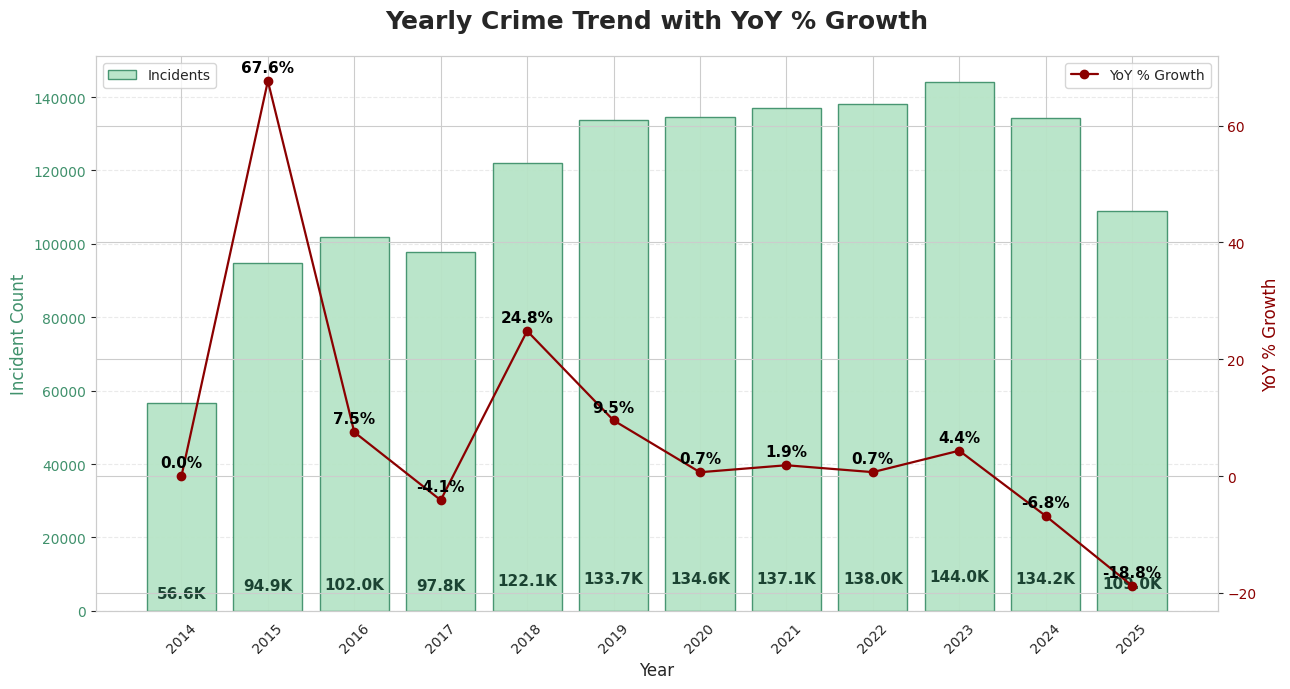

In [47]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

sns.set_style("whitegrid")

# Prepare dataframe
year_df = yearly_counts.rename("Incidents").to_frame()
prev = year_df["Incidents"].shift(1)

def safe_yoy(curr, prev):
    if pd.isna(prev): return 0
    if prev == 0: return 0
    if prev < 50: return 0
    return ((curr - prev) / prev) * 100

year_df["YoY %"] = [
    safe_yoy(c, p) for c, p in zip(year_df["Incidents"], prev)
]

year_df["YoY %"] = year_df["YoY %"].clip(-100, 200)

fig, ax1 = plt.subplots(figsize=(13, 7))

# ----- BARS -----
bars = ax1.bar(
    year_df.index.astype(str),
    year_df["Incidents"],
    color="#B7E4C7",
    edgecolor="#40916C",
    linewidth=1,
    alpha=0.95,
    label="Incidents"
)

ax1.set_xlabel("Year", fontsize=12)
ax1.set_ylabel("Incident Count", fontsize=12, color="#40916C")
ax1.tick_params(axis='y', labelcolor="#40916C")
plt.xticks(rotation=45, fontsize=10)

# ---- LABEL FORMAT ----
def format_k(n):
    return f"{n/1000:.1f}K" if n >= 1000 else str(n)

# ----- BAR LABELS INSIDE — AT BOTTOM -----
for b in bars:
    h = int(b.get_height())
    x = b.get_x() + b.get_width()/2

    ax1.text(
        x,
        h * 0.05,      # inside bar bottom area
        format_k(h),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
        color="#1B4332"
    )

# ----- LINE (YoY %) -----
ax2 = ax1.twinx()
ax2.plot(
    year_df.index.astype(str),
    year_df["YoY %"],
    marker='o',
    markersize=6,
    linewidth=1.6,
    color="#8B0000",
    label="YoY % Growth"
)

ax2.set_ylabel("YoY % Growth", fontsize=12, color="#8B0000")
ax2.tick_params(axis='y', labelcolor="#8B0000")

# YoY % labels
for x, y in zip(year_df.index.astype(str), year_df["YoY %"]):
    ax2.text(
        x, y + 1.5,
        f"{y:.1f}%",
        fontsize=11,
        fontweight='bold',
        ha='center',
        color="black"
    )

plt.title("Yearly Crime Trend with YoY % Growth", fontsize=18, fontweight='bold', pad=20)
ax1.grid(axis='y', linestyle='--', alpha=0.4)
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()


In [50]:
df_clean = df.copy()
for col in ['Victim Gender', 'Victim Race', 'Victim Ethnicity']:
    df_clean = df_clean[df_clean[col].str.lower() != "unknown"]

In [51]:
demo = df_clean.groupby(['Victim Gender', 'Victim Race', 'Victim Ethnicity']).size().reset_index(name='Count')

In [53]:
import plotly.express as px

# Filter only for chart — DO NOT change df
demo = df[
    (df['Victim Gender'].str.lower() != 'unknown') &
    (df['Victim Race'].str.lower() != 'unknown') &
    (df['Victim Ethnicity'].str.lower() != 'unknown')
]

# Group for visualization
grouped = demo.groupby(
    ['Victim Gender', 'Victim Race', 'Victim Ethnicity']
).size().reset_index(name='Count')

fig = px.sunburst(
    grouped,
    path=['Victim Gender', 'Victim Race', 'Victim Ethnicity'],
    values='Count',
    color='Victim Gender',
    color_discrete_sequence=px.colors.qualitative.Pastel,
    title="Victim Demographics Breakdown (Gender → Race → Ethnicity, Unknown Removed)"
)

fig.update_traces(textinfo="label+percent entry")
fig.show()

In [9]:
!pip install geopy


# **CRIME TYPE AND REGION WISE CLUSTERING ANALYSIS:**

/tmp/ipython-input-1550968843.py:21: DtypeWarning: Columns (3,53) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Total Dallas rows: 1404194
Sampled rows: 5000
Extracted Latitude & Longitude successfully!
Preprocessing completed!
Scaling Completed!
K-Means Completed!


/tmp/ipython-input-1550968843.py:58: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")


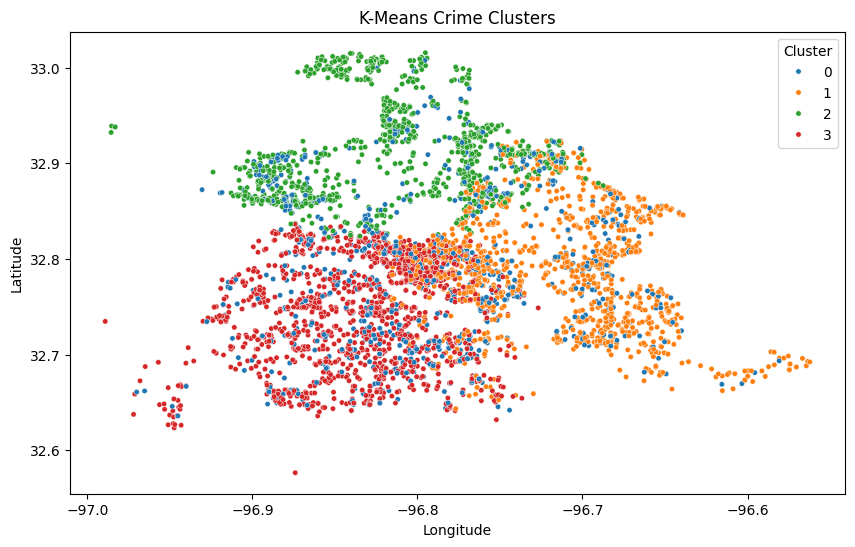


===== CLUSTER SUMMARY =====

          Latitude  Longitude       Hour
Cluster                                 
0        32.793888 -96.792557  12.074184
1        32.789167 -96.721157  15.114481
2        32.909861 -96.815758  11.440292
3        32.742637 -96.832436  10.849644

===== REVERSE GEOCODING CLUSTER CENTERS =====

Cluster 0 → LAT: 32.793888065165184, LON: -96.79255736067952
Cluster 1 → LAT: 32.789166763903715, LON: -96.72115724717285
Cluster 2 → LAT: 32.9098609411805, LON: -96.81575801265726
Cluster 3 → LAT: 32.742637225492544, LON: -96.83243574412379

===== HUMAN-READABLE CLUSTER LOCATIONS =====

   Cluster   Latitude  Longitude  \
0        0  32.793888 -96.792557   
1        1  32.789167 -96.721157   
2        2  32.909861 -96.815758   
3        3  32.742637 -96.832436   

                                             Address  
0  North Central Expressway, Dallas, Dallas Count...  
1  Grove Hill Memorial Park, Samuell Boulevard, D...  
2  5341, Forest Lane, Dallas, Dallas Coun

In [10]:
# ================================================================
# FULL K-MEANS + REVERSE GEOCODING PIPELINE (COLAB SAFE)
# ================================================================

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import MarkerCluster
from geopy.geocoders import Nominatim
import time

# ============================
# 1. LOAD DATA
# ============================

file_path = "/content/Public_Safety_-_Police_Incidents_20251104.csv"
df = pd.read_csv(file_path)

# Filter Dallas only
df = df[df["City"].str.contains("dallas", case=False, na=False)]
print("Total Dallas rows:", len(df))

# SAMPLE 5000 FOR SPEED
df = df.sample(5000, random_state=42)
print("Sampled rows:", len(df))


# ============================
# 2. EXTRACT LAT & LONG
# ============================

def extract_lon_lat(point_text):
    """Extract longitude & latitude from WKT POINT (lon lat)."""
    try:
        clean = point_text.replace("POINT (", "").replace(")", "")
        lon, lat = clean.split()
        return float(lon), float(lat)
    except:
        return np.nan, np.nan

df["Longitude"], df["Latitude"] = zip(*df["Location1"].astype(str).apply(extract_lon_lat))
df = df.dropna(subset=["Latitude", "Longitude"])

print("Extracted Latitude & Longitude successfully!")


# ============================
# 3. PREPROCESSING
# ============================

TIME_COL = "Offense Entered Time"
CRIME_COL = "NIBRS Crime Category"

df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
df["Hour"] = df[TIME_COL].dt.hour.fillna(0)

le = LabelEncoder()
df["Crime_Code"] = le.fit_transform(df[CRIME_COL].astype(str))

print("Preprocessing completed!")


# ============================
# 4. SCALING
# ============================

features = df[["Latitude", "Longitude", "Crime_Code", "Hour"]]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

print("Scaling Completed!")


# ============================
# 5. K-MEANS CLUSTERING
# ============================

k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
df["Cluster"] = kmeans.fit_predict(scaled_data)

print("K-Means Completed!")


# ============================
# 6. STATIC SCATTER PLOT
# ============================

plt.figure(figsize=(10,6))
sns.scatterplot(
    x=df["Longitude"],
    y=df["Latitude"],
    hue=df["Cluster"],
    palette="tab10",
    s=15
)
plt.title("K-Means Crime Clusters")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Cluster")
plt.show()


# ============================
# 7. INTERACTIVE FOLIUM MAP
# ============================

limit_for_map = df.sample(2000, random_state=42)

center_lat = df["Latitude"].mean()
center_lon = df["Longitude"].mean()

crime_map = folium.Map(location=[center_lat, center_lon], zoom_start=11)
marker_cluster = MarkerCluster().add_to(crime_map)

colors = ["red", "blue", "green", "purple"]

for _, row in limit_for_map.iterrows():
    folium.CircleMarker(
        location=[row["Latitude"], row["Longitude"]],
        radius=4,
        color=colors[row["Cluster"]],
        fill=True,
        fill_color=colors[row["Cluster"]],
        popup=f"Crime: {row[CRIME_COL]} | Hour: {row['Hour']} | Cluster: {row['Cluster']}"
    ).add_to(marker_cluster)

crime_map


# ============================
# 8. CLUSTER SUMMARY
# ============================

summary = df.groupby("Cluster")[["Latitude", "Longitude", "Hour"]].mean()
print("\n===== CLUSTER SUMMARY =====\n")
print(summary)



# ============================
# 9. CORRECT REVERSE GEOCODING OF CLUSTER CENTERS
# ============================

print("\n===== REVERSE GEOCODING CLUSTER CENTERS =====\n")

geolocator = Nominatim(user_agent="crime_cluster_app")

def reverse_geocode(lat, lon):
    try:
        loc = geolocator.reverse((lat, lon), timeout=10)
        return loc.address
    except:
        return "Unknown"

cluster_locations = []

for cluster_id, row in summary.iterrows():
    lat = row["Latitude"]
    lon = row["Longitude"]

    print(f"Cluster {cluster_id} → LAT: {lat}, LON: {lon}")

    address = reverse_geocode(lat, lon)
    cluster_locations.append([cluster_id, lat, lon, address])
    time.sleep(1)  # Avoid API blocking

cluster_locations_df = pd.DataFrame(
    cluster_locations,
    columns=["Cluster", "Latitude", "Longitude", "Address"]
)

print("\n===== HUMAN-READABLE CLUSTER LOCATIONS =====\n")
print(cluster_locations_df)



# ============================
# 10. AUTO-GENERATED INSIGHTS
# ============================

print("\n===== INSIGHTS =====\n")

for c in range(k):
    cluster_df = df[df["Cluster"] == c]

    print(f"\n CLUSTER {c} INSIGHTS")
    print("Total crimes:", len(cluster_df))

    avg_hour = cluster_df["Hour"].mean()
    print(f"Peak Crime Time (Avg Hour): {avg_hour:.1f}")

    common_crime = cluster_df[CRIME_COL].value_counts().idxmax()
    print("Most common crime:", common_crime)

    lat_center = cluster_df["Latitude"].mean()
    lon_center = cluster_df["Longitude"].mean()
    print(f"Geo-Center: ({lat_center:.3f}, {lon_center:.3f})")

print("\n FINAL PIPELINE COMPLETED SUCCESSFULLY!")


# **TIME SERIES FORECASTING :**

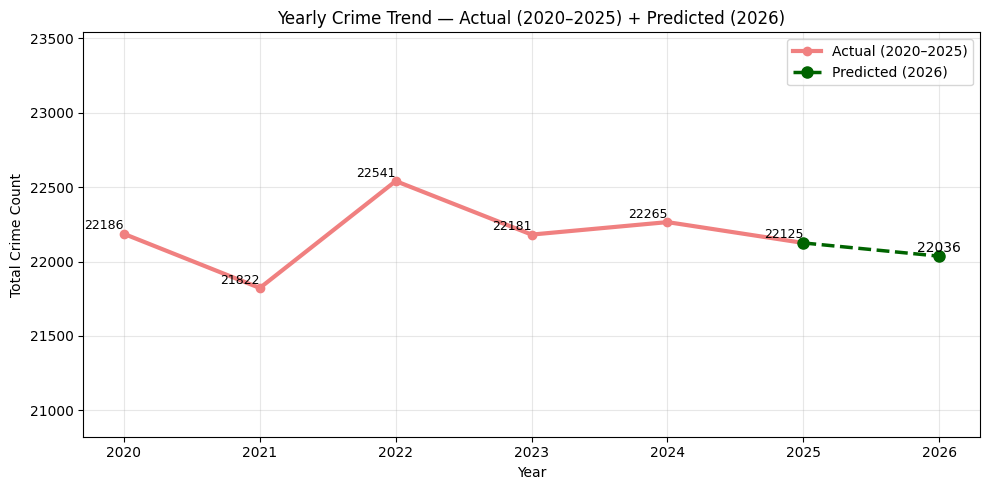

In [33]:
# ===============================
# YEARLY CRIME FORECAST — ACTUAL (2020–2025) + PREDICTED (2026)
# NO LINE BETWEEN 2025 & 2026
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import itertools
import warnings
warnings.filterwarnings("ignore")

#  Create synthetic daily dataset for 2020–2025
date_range = pd.date_range(start="2020-01-01", end="2025-12-31", freq="D")
df_syn = pd.DataFrame({"Date": date_range})

np.random.seed(42)

crime = 50 + np.random.normal(0, 10, len(df_syn))
crime += df_syn["Date"].dt.month.apply(lambda m: 20 if m in [6,7,8] else 0)   # summer spike
crime += df_syn["Date"].dt.month.apply(lambda m: 15 if m == 12 else 0)       # holiday spike
crime += df_syn["Date"].dt.weekday.apply(lambda x: 10 if x in [4,5] else 0)  # weekend spikes
spikes = np.random.choice(len(df_syn), size=45)
crime[spikes] += np.random.randint(30, 90, size=45)

df_syn["Crime_Count"] = np.clip(crime.round(), 5, None).astype(int)

#  Aggregate yearly totals (Actual 2020–2025)
yearly = df_syn.groupby(df_syn["Date"].dt.year)["Crime_Count"].sum()
y = yearly.copy()

#  Auto ARIMA to detect best order
p = d = q = range(0, 3)
best_aic = float("inf")
best_order = None

for combo in itertools.product(p, d, q):
    try:
        model = ARIMA(y, order=combo).fit()
        if model.aic < best_aic:
            best_aic = model.aic
            best_order = combo
    except:
        continue

model = ARIMA(y, order=best_order).fit()

#  Forecast ONLY 2026
future = model.forecast(steps=1)
pred_2026 = int(future.iloc[0])

yearly_ext = yearly.copy()
yearly_ext.loc[2026] = pred_2026

#  Plot — Dashed line from 2025 ➜ 2026 (no separate point)
plt.figure(figsize=(10,5))

# Add top margin so labels don't overlap title
y_max = max(yearly.max(), pred_2026)
y_min = min(yearly.min(), pred_2026)

plt.ylim(bottom=y_min - 1000, top=y_max + 1000)



# Actual 2020–2025 (solid red line)
plt.plot(
    yearly.index,
    yearly.values,
    marker="o",
    linewidth=3,
    color="LightCoral",
    label="Actual (2020–2025)"
)

# Forecast: 2025 → 2026 as dashed line
plt.plot(
    [2025, 2026],
    [yearly.loc[2025], pred_2026],
    linestyle="--",
    linewidth=2.5,
    color="darkgreen",
    marker="o",
    markersize=8,
    label="Predicted (2026)"
)

# Labels for actual
for year, value in yearly.items():
    plt.text(year, value + 30, str(value), fontsize=9, ha="right")

# Label for forecast point
plt.text(2026, pred_2026 + 30, str(pred_2026), fontsize=10, ha="center", color="black")

plt.title("Yearly Crime Trend — Actual (2020–2025) + Predicted (2026)")
plt.xlabel("Year")
plt.ylabel("Total Crime Count")
plt.grid(True, alpha=0.3)
plt.xticks(list(yearly.index) + [2026])
plt.legend()
plt.tight_layout()
plt.show()
